In [122]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

#2 задание
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.metrics import confusion_matrix

In [123]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("x_train:", x_train.shape, x_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("x_test :", x_test.shape, x_test.dtype)
print("y_test :", y_test.shape, y_test.dtype)

x_train: (60000, 28, 28) uint8
y_train: (60000,) uint8
x_test : (10000, 28, 28) uint8
y_test : (10000,) uint8


In [124]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("После нормализации:")
print("min/max x_train:", x_train.min(), x_train.max())

После нормализации:
min/max x_train: 0.0 1.0


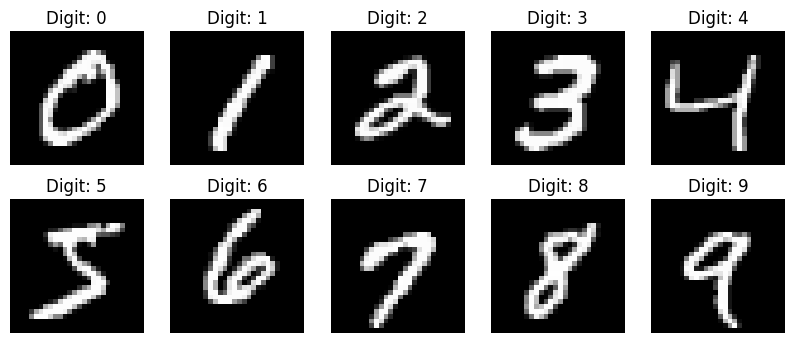

In [125]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for n in range(10):
    idx = np.where(y_train == n)[0][0]   # первый пример цифры d
    axes[n].imshow(x_train[idx], cmap="gray")
    axes[n].set_title(f"Digit: {n}")
    axes[n].axis("off")

plt.show()

In [126]:
x_train_vec = x_train.reshape(x_train.shape[0], 28*28)
x_test_vec  = x_test.reshape(x_test.shape[0], 28*28)

print("x_train_vec:", x_train_vec.shape)
print("x_test_vec :", x_test_vec.shape)

x_train_vec: (60000, 784)
x_test_vec : (10000, 784)


Задание №2

In [127]:
def build_model(n1, n2=None, use_dropout=False, dropout_rate=0.2):
    model = Sequential()
    model.add(Input(shape=(784,)))

    # 1-й скрытый слой
    model.add(Dense(n1, activation="relu"))

    # dropout после 1-го скрытого слоя (если включен)
    if use_dropout:
        model.add(Dropout(dropout_rate))

    # 2-й скрытый слой (если задан)
    if n2 is not None:
        model.add(Dense(n2, activation="relu"))
        if use_dropout:
            model.add(Dropout(dropout_rate))

    # выходной слой
    model.add(Dense(10, activation="softmax"))

    return model

In [128]:
model = build_model(n1=128, n2=64, use_dropout=True, dropout_rate=0.2)

model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_110 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Обучение с отложенной валидацией

In [129]:

history = model.fit(
    x_train_vec, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

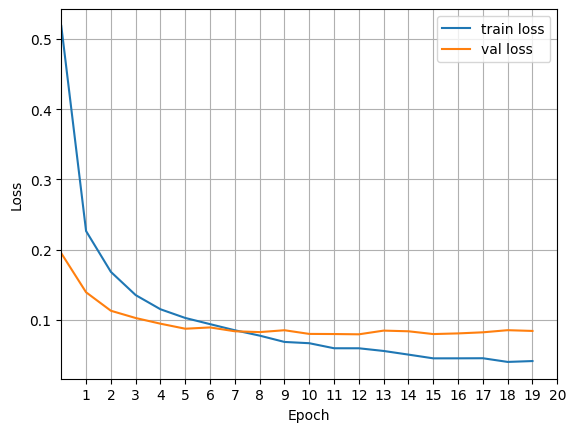

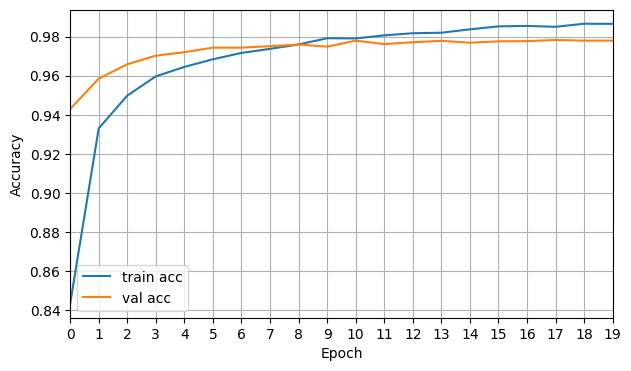

In [130]:
# 1) Loss
epochs = len(history.history["loss"])
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")

plt.xticks(np.arange(1, epochs + 1, 1))  # 1,2,3,...,epochs
plt.xlim(0, epochs)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# 2) Accuracy
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")

plt.xticks(np.arange(0, epochs, 1))  # 0,1,2,...,epochs-1
plt.xlim(0, epochs-1)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Задание №3

Оценка качества и loss на тесте через evaluate

In [131]:
test_loss, test_metric = model.evaluate(x_test_vec, y_test, verbose=0)
print(f"Test loss (evaluate): {test_loss:.6f}")
print(f"Test accuracy (evaluate): {test_metric:.6f}")

Test loss (evaluate): 0.079846
Test accuracy (evaluate): 0.977900


Классификация теста

In [132]:
y_prob = model.predict(x_test_vec, verbose=1)   # (10000, 10)
y_pred = y_prob.argmax(axis=1)                 # (10000,)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

Confusion Matrix

In [133]:

cm = confusion_matrix(y_test, y_pred)  # y_test и y_pred: (N,)
acc_cm = cm.diagonal().sum() / cm.sum()
print(f'Accuracy (confusion matrix): {acc_cm:.4f}')

Accuracy (confusion matrix): 0.9779


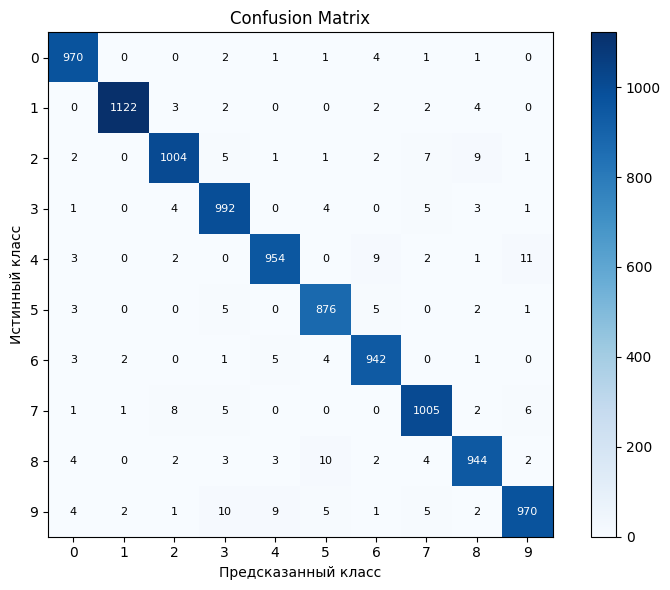

In [134]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(im, ax=ax)

ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')
ax.set_title('Confusion Matrix')

ax.set_xticks(range(10))
ax.set_yticks(range(10))

# подписи внутри клеток
threshold = cm.max() / 2
for i in range(10):
    for j in range(10):
        ax.text(
            j, i, cm[i, j],
            ha='center', va='center',
            color='white' if cm[i, j] > threshold else 'black',
            fontsize=8
        )

plt.tight_layout()
plt.show()

In [135]:
test_loss, test_acc = model.evaluate(x_test_vec, y_test, verbose=0)
print(f"Accuracy (evaluate): {test_acc:.4f}")
print(f"Accuracy (confusion matrix): {acc_cm:.4f}")
print(f"Abs diff: {abs(test_acc - acc_cm):.8f}")

Accuracy (evaluate): 0.9779
Accuracy (confusion matrix): 0.9779
Abs diff: 0.00000003


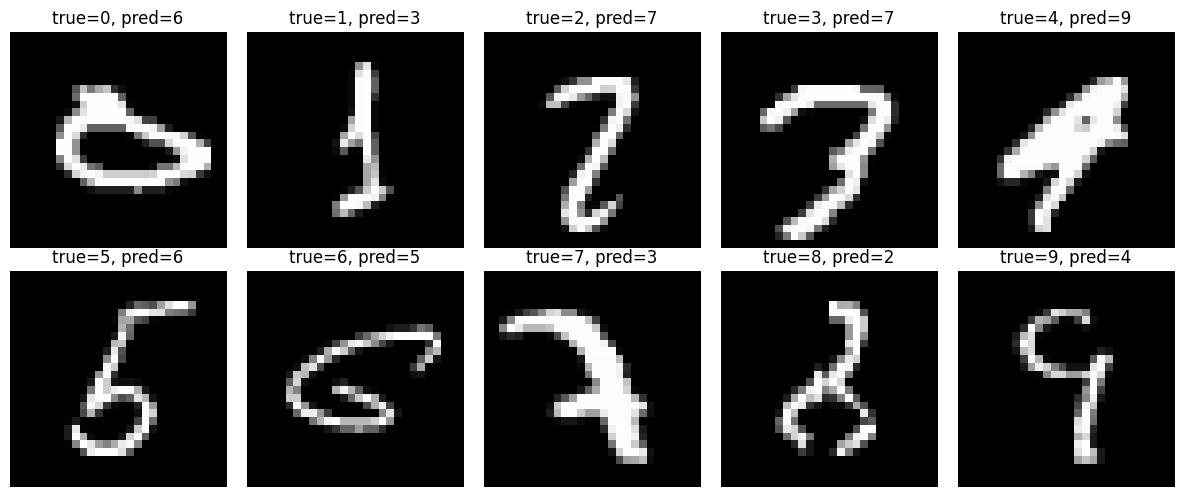

In [136]:

x_test_img = x_test

wrong_mask = (y_pred != y_test)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for cls in range(10):
    # индексы, где истинный класс = cls и при этом ошибка
    idxs = np.where((y_test == cls) & wrong_mask)[0]

    ax = axes[cls]
    if len(idxs) == 0:
        ax.set_title(f"true={cls}: ошибок нет ✅")
        ax.axis("off")
        continue

    i = idxs[1]
    ax.imshow(x_test_img[i], cmap="gray")
    ax.set_title(f"true={cls}, pred={y_pred[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Задание №4

In [137]:
param_grid = {
    "n1": [32, 64, 128, 256],
    "batch_size": [32, 64, 128, 256],
}

In [138]:
results = []
epochs_count = 10  # для подбора (можно 8–12)

for n1 in param_grid["n1"]:
    for bs in param_grid["batch_size"]:
        model = build_model(n1)
        model.compile(
            loss=SparseCategoricalCrossentropy(),
            optimizer="adam",
            metrics=["accuracy"]
        )
        history = model.fit(
            x_train_vec, y_train,
            epochs=epochs_count,
            batch_size=bs,
            validation_split=0.2,
            verbose=0
        )

        best_val_acc = float(np.max(history.history["val_accuracy"]))
        best_val_loss = float(np.min(history.history["val_loss"]))

        results.append({
            "n1": n1,
            "batch_size": bs,
            "best_val_accuracy": best_val_acc,
            "best_val_loss": best_val_loss
        })

        print(f"n1={n1:3d} bs={bs:3d}  best_val_acc={best_val_acc:.4f}  best_val_loss={best_val_loss:.4f}")

n1= 32 bs= 32  best_val_acc=0.9670  best_val_loss=0.1205
n1= 32 bs= 64  best_val_acc=0.9637  best_val_loss=0.1233
n1= 32 bs=128  best_val_acc=0.9595  best_val_loss=0.1429
n1= 32 bs=256  best_val_acc=0.9564  best_val_loss=0.1571
n1= 64 bs= 32  best_val_acc=0.9729  best_val_loss=0.0964
n1= 64 bs= 64  best_val_acc=0.9705  best_val_loss=0.1018
n1= 64 bs=128  best_val_acc=0.9682  best_val_loss=0.1073
n1= 64 bs=256  best_val_acc=0.9661  best_val_loss=0.1184
n1=128 bs= 32  best_val_acc=0.9771  best_val_loss=0.0870
n1=128 bs= 64  best_val_acc=0.9754  best_val_loss=0.0850
n1=128 bs=128  best_val_acc=0.9730  best_val_loss=0.0901
n1=128 bs=256  best_val_acc=0.9737  best_val_loss=0.0893
n1=256 bs= 32  best_val_acc=0.9789  best_val_loss=0.0788
n1=256 bs= 64  best_val_acc=0.9778  best_val_loss=0.0793
n1=256 bs=128  best_val_acc=0.9774  best_val_loss=0.0778
n1=256 bs=256  best_val_acc=0.9764  best_val_loss=0.0803


In [139]:
results_sorted = sorted(results, key=lambda d: d["best_val_accuracy"], reverse=True)
best = results_sorted[0]

print("\n✅ Лучшие найденные параметры:")
print(f"n1 = {best['n1']}")
print(f"batch_size = {best['batch_size']}")
print(f"best_val_accuracy = {best['best_val_accuracy']:.4f}")
print(f"best_val_loss = {best['best_val_loss']:.4f}")


✅ Лучшие найденные параметры:
n1 = 256
batch_size = 32
best_val_accuracy = 0.9789
best_val_loss = 0.0788


In [140]:
best_model = build_model(best["n1"])

best_model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer="adam",
    metrics=["accuracy"]
)


history_best = best_model.fit(
    x_train_vec, y_train,
    epochs=20,
    batch_size=best["batch_size"],
    validation_split=0.2,
    verbose=1
)

test_loss, test_acc = best_model.evaluate(x_test_vec, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9279 - loss: 0.2480 - val_accuracy: 0.9591 - val_loss: 0.1372
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9690 - loss: 0.1038 - val_accuracy: 0.9703 - val_loss: 0.0994
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9790 - loss: 0.0680 - val_accuracy: 0.9701 - val_loss: 0.0999
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9857 - loss: 0.0472 - val_accuracy: 0.9745 - val_loss: 0.0881
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9886 - loss: 0.0361 - val_accuracy: 0.9749 - val_loss: 0.0864
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9916 - loss: 0.0269 - val_accuracy: 0.9758 - val_loss: 0.0856
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9937 - loss: 0.0202 - val_accuracy: 0.9768 - val_loss: 0.0823
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9950 - loss: 0.0169 - 

Задание №5

In [141]:
def params_1(n1):
    return 795*n1 + 10

def params_2(n1, n2):
    return n1*n2 + 785*n1 + 11*n2 + 10

In [142]:
def build_model_1(n1, use_dropout=False, dropout_rate=0.2):
    m = Sequential()
    m.add(Input(shape=(784,)))
    m.add(Dense(n1, activation="relu"))
    if use_dropout:
        m.add(Dropout(dropout_rate))
    m.add(Dense(10, activation="softmax"))
    m.compile(loss=SparseCategoricalCrossentropy(), optimizer="adam", metrics=["accuracy"])
    return m

def build_model_2(n1, n2, use_dropout=False, dropout_rate=0.2):
    m = Sequential()
    m.add(Input(shape=(784,)))
    m.add(Dense(n1, activation="relu"))
    if use_dropout:
        m.add(Dropout(dropout_rate))
    m.add(Dense(n2, activation="relu"))
    if use_dropout:
        m.add(Dropout(dropout_rate))
    m.add(Dense(10, activation="softmax"))
    m.compile(loss=SparseCategoricalCrossentropy(), optimizer="adam", metrics=["accuracy"])
    return m

In [143]:
configs = [
    {"name":"1L n1=112 bs=64  noDO", "builder": lambda: build_model_1(112, False), "bs":64},
    {"name":"1L n1=112 bs=64  DO",   "builder": lambda: build_model_1(112, True, 0.2), "bs":64},
    {"name":"1L n1=112 bs=256 noDO", "builder": lambda: build_model_1(112, False), "bs":256},
    {"name":"1L n1=112 bs=256 DO",   "builder": lambda: build_model_1(112, True, 0.2), "bs":256},

    {"name":"2L (112,32) bs=64  noDO", "builder": lambda: build_model_2(112, 32, False), "bs":64},
    {"name":"2L (112,32) bs=64  DO",   "builder": lambda: build_model_2(112, 32, True, 0.2), "bs":64},
    {"name":"2L (112,32) bs=256 noDO", "builder": lambda: build_model_2(112, 32, False), "bs":256},
    {"name":"2L (112,32) bs=256 DO",   "builder": lambda: build_model_2(112, 32, True, 0.2), "bs":256},
]

In [144]:
EPOCHS = 20
histories = {}

for cfg in configs:
    model = cfg["builder"]()
    h = model.fit(
        x_train_vec, y_train,
        epochs=EPOCHS,
        batch_size=cfg["bs"],
        validation_split=0.2,
        verbose=0
    )
    histories[cfg["name"]] = h.history

    # печать итогов для отчёта
    last_val_acc = h.history["val_accuracy"][-1]
    last_val_loss = h.history["val_loss"][-1]
    print(f"{cfg['name']}: val_acc={last_val_acc:.4f}, val_loss={last_val_loss:.4f}")

1L n1=112 bs=64  noDO: val_acc=0.9753, val_loss=0.1107
1L n1=112 bs=64  DO: val_acc=0.9782, val_loss=0.0825
1L n1=112 bs=256 noDO: val_acc=0.9736, val_loss=0.0863
1L n1=112 bs=256 DO: val_acc=0.9767, val_loss=0.0798
2L (112,32) bs=64  noDO: val_acc=0.9751, val_loss=0.1350
2L (112,32) bs=64  DO: val_acc=0.9772, val_loss=0.0891
2L (112,32) bs=256 noDO: val_acc=0.9758, val_loss=0.0913
2L (112,32) bs=256 DO: val_acc=0.9768, val_loss=0.0859


LOSS

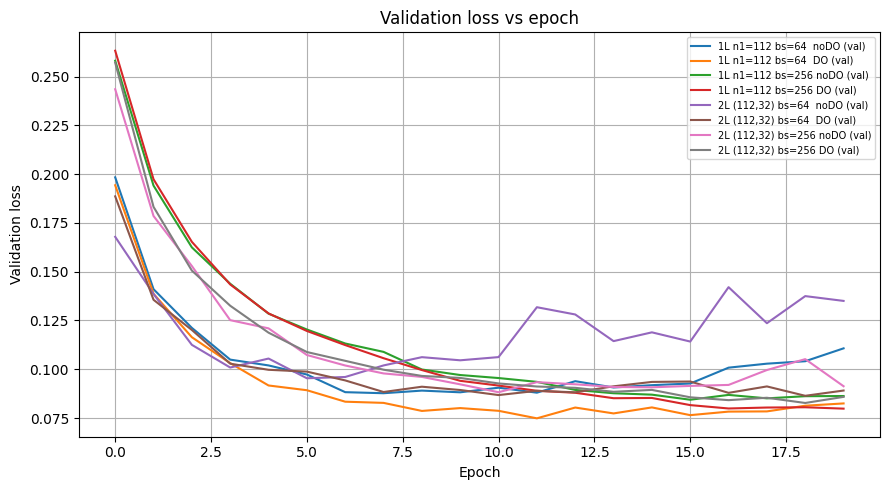

In [145]:
plt.figure(figsize=(9, 5))
for name, h in histories.items():
    plt.plot(h["val_loss"], label=f"{name} (val)")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss vs epoch")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()

Accuracy

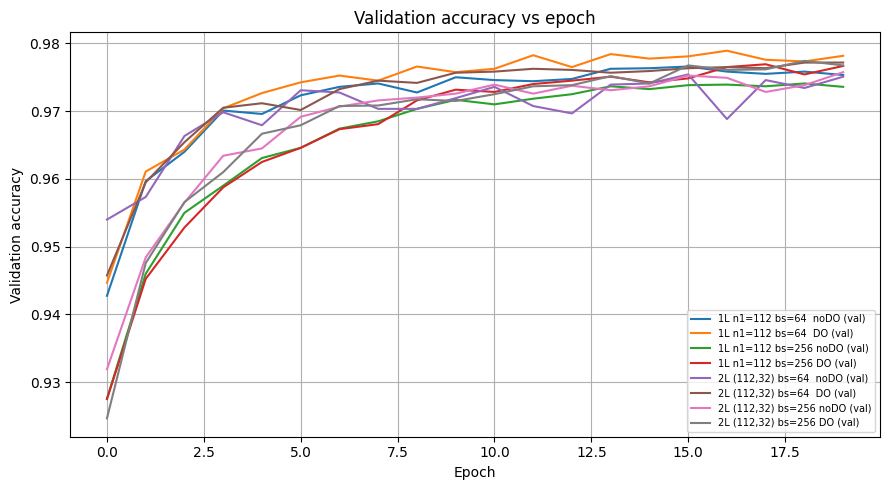

In [146]:
plt.figure(figsize=(9, 5))
for name, h in histories.items():
    plt.plot(h["val_accuracy"], label=f"{name} (val)")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy vs epoch")
plt.legend(fontsize=7)
plt.grid(True)
plt.tight_layout()
plt.show()